# step 1 导入库

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# step 2 读取数据

In [2]:
data = pd.read_json("./福大教务处消息.txt")
data

,标题,通知人,日期,正文地址,附件
0,关于开展本科生实习教学专项检查的通知,质量办,2026-09-20,https://jwch.fzu.edu.cn/info/1040/14822.htm,"[{'序号': 1, '标题': '附件1：《教育部等六部门关于加强普通本科高校大学生实习工..."
1,关于开展“AI辅助教学、助力课堂创新”智慧教学第十一期培训的通知,电教中心,2026-09-18,https://jwch.fzu.edu.cn/info/1041/14820.htm,None
2,关于通识教育选修课《国际化拔尖创新人才科研训练2026秋》宣讲会及选课的通知,计划科,2026-09-15,https://jwch.fzu.edu.cn/info/1038/14817.htm,"[{'序号': 1, '标题': '2026年秋季国际化拔尖创新人才科研训练具体课程清单.x..."
3,关于召开2026-2027学年秋季学期期初本科教育教学工作会议的通知,综合科,2026-09-15,https://jwch.fzu.edu.cn/info/1035/14816.htm,None
4,关于开展福州大学2026年教师教学创新大赛的通知,质量办,2026-09-15,https://jwch.fzu.edu.cn/info/1040/14813.htm,"[{'序号': 1, '标题': '附件3：福州大学一流课程名单（国56省182校192）及..."
...,...,...,...,...,...
157,关于2025年国庆节、中秋节放假课程调整的通知,教学运行,2025-09-24,https://jwch.fzu.edu.cn/info/1036/14229.htm,None
158,关于召开2025-2026学年秋季学期期初本科教育教学工作会议的通知,综合科,2025-09-23,https://jwch.fzu.edu.cn/info/1035/14228.htm,None
159,关于做好2025-2026学年第二学期排课准备工作的通知,教学运行,2025-09-22,https://jwch.fzu.edu.cn/info/1036/14225.htm,None
160,关于2025-2026学年第一学期重新学习选课、缴费的通知,教学运行,2025-09-22,https://jwch.fzu.edu.cn/info/1036/14224.htm,None


In [3]:
type(data)

pandas.DataFrame

# step 3 数据初分析

In [4]:
data["日期"] = pd.to_datetime(data["日期"])
data.head()

,标题,通知人,日期,正文地址,附件
0,关于开展本科生实习教学专项检查的通知,质量办,2026-09-20,https://jwch.fzu.edu.cn/info/1040/14822.htm,"[{'序号': 1, '标题': '附件1：《教育部等六部门关于加强普通本科高校大学生实习工..."
1,关于开展“AI辅助教学、助力课堂创新”智慧教学第十一期培训的通知,电教中心,2026-09-18,https://jwch.fzu.edu.cn/info/1041/14820.htm,None
2,关于通识教育选修课《国际化拔尖创新人才科研训练2026秋》宣讲会及选课的通知,计划科,2026-09-15,https://jwch.fzu.edu.cn/info/1038/14817.htm,"[{'序号': 1, '标题': '2026年秋季国际化拔尖创新人才科研训练具体课程清单.x..."
3,关于召开2026-2027学年秋季学期期初本科教育教学工作会议的通知,综合科,2026-09-15,https://jwch.fzu.edu.cn/info/1035/14816.htm,None
4,关于开展福州大学2026年教师教学创新大赛的通知,质量办,2026-09-15,https://jwch.fzu.edu.cn/info/1040/14813.htm,"[{'序号': 1, '标题': '附件3：福州大学一流课程名单（国56省182校192）及..."


In [5]:
data.sample(10)

,标题,通知人,日期,正文地址,附件
35,关于2025-2026学年第二学期《高等数学A（中）》、《高等数学B（下）》和《高等数学C（...,教学运行,2026-06-26,https://jwch.fzu.edu.cn/info/1036/14712.htm,"[{'序号': 1, '标题': '2502高等数学A（中）、B（下）、C（下）期末考-7...."
110,关于2025-2026学年第一学期《高等数学A（上）》、《高等数学B（上）》、《高等数学C（...,教学运行,2026-01-13,https://jwch.fzu.edu.cn/info/1036/14493.htm,"[{'序号': 1, '标题': '2501高等数学A（上）、B（上）期末考-1.30上午...."
30,关于更改2025-2026学年春季学期期末本科教育教学工作会议地点的通知,综合科,2026-07-02,https://jwch.fzu.edu.cn/info/1035/14722.htm,None
60,福州大学关于印发2026—2027学年校历的通知,教学运行,2026-05-19,https://jwch.fzu.edu.cn/info/1036/14639.htm,None
142,福州大学关于印发教材委员会章程的通知,教学通知,2025-11-18,https://jwch.fzu.edu.cn/info/1012/14362.htm,None
43,关于举办福州大学第八十六场“教学有道”研讨活动的通知,实践科,2026-06-16,https://jwch.fzu.edu.cn/info/1040/14691.htm,None
11,关于公布参加2026级“数理综合班”选拔面试学生名单的通知,教研教改,2026-09-09,https://jwch.fzu.edu.cn/info/1037/14788.htm,None
147,关于公布福州大学2025年教师教学创新大赛—入围教学设计创新汇报名单的通知,质量办,2025-11-12,https://jwch.fzu.edu.cn/info/1040/14341.htm,None
69,关于2025-2026学年第二学期《线性代数》课程半期考试安排的通知,教学运行,2026-04-27,https://jwch.fzu.edu.cn/info/1036/14606.htm,"[{'序号': 1, '标题': '2502线代半期考-5.10下午.xlsx', '附件下..."
117,关于2026届预计毕业生校对电子注册学历照片的通知,教学运行,2026-01-09,https://jwch.fzu.edu.cn/info/1036/14484.htm,None


In [6]:
data.describe()

,日期
count,162
mean,2026-04-02 05:20:00
min,2025-09-22 00:00:00
25%,2026-01-06 00:00:00
50%,2026-04-08 00:00:00
75%,2026-06-18 00:00:00
max,2026-09-20 00:00:00


## 获取通知人的数量与占比

['教学运行' '实践科' '计划科' '教材建设' '质量办' '教研教改' '综合科' '电教中心' '教学通知']
[59 23 18 17 14 13 11  4  3]


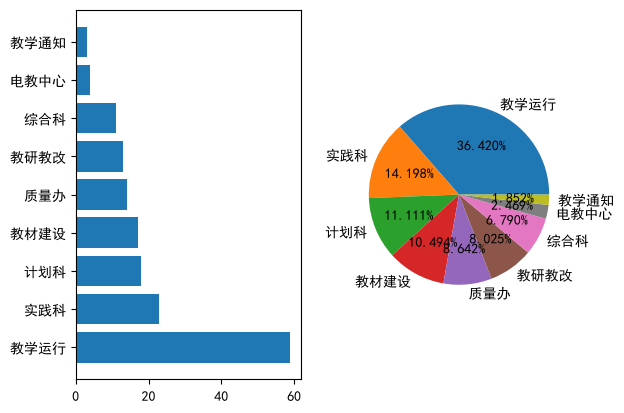

In [ ]:
# 中文字体显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']

imformant_count = data["通知人"].value_counts()
imformant_ratio = data["通知人"].value_counts(normalize=True) * 100

imformant_data = pd.DataFrame({
    "数量": imformant_count, 
    "占比（%）": imformant_ratio
})

categories = np.array(imformant_count.index.tolist())
values = np.array(imformant_count.values.tolist())

print(categories)
print(values)

figure, axes = plt.subplots(1, 2)

axes[0].barh(categories, values)

axes[1].pie(values, labels=categories,
                    autopct="%1.3f%%")

plt.show()

## 获取标题中含 “课程调整” 的数据


In [8]:
list = []
quantity = 0
num = 0
for x in data["标题"]:
    if re.search(r"课程调整", x) != None:
        quantity += 1
        list.append(data.iloc[num])
    num += 1
lesson_adjustment_df = pd.DataFrame(list)
print(f"通知数：{quantity}")
print(lesson_adjustment_df)
lesson_adjustment_df.to_csv(r"./课程调整通知.csv")
print("数据写入成功")


通知数：6
                          标题   通知人         日期  \
6    关于2026年中秋节和国庆节放假课程调整的通知  教学运行 2026-09-14   
44       关于2026年端午节放假课程调整的通知  教学运行 2026-06-15   
71       关于2026年劳动节放假课程调整的通知  教学运行 2026-04-24   
86       关于2026年清明节放假课程调整的通知   实践科 2026-03-30   
128       关于2026年元旦放假课程调整的通知  教学运行 2025-12-29   
157  关于2025年国庆节、中秋节放假课程调整的通知  教学运行 2025-09-24   

                                            正文地址    附件  
6    https://jwch.fzu.edu.cn/info/1036/14811.htm  None  
44   https://jwch.fzu.edu.cn/info/1036/14690.htm  None  
71   https://jwch.fzu.edu.cn/info/1036/14601.htm  None  
86   https://jwch.fzu.edu.cn/info/1036/14562.htm  None  
128  https://jwch.fzu.edu.cn/info/1036/14431.htm  None  
157  https://jwch.fzu.edu.cn/info/1036/14229.htm  None  
数据写入成功


## 获取含附件的消息

In [34]:
list_with_attachment = []

# 获取含附件的消息列表
for idx, row in data.iterrows():
    attachments_list = row["附件"]
    if attachments_list != None:
        num_of_attachment = len(attachments_list)
        all_download_quantity_of_attachment = 0
        for one_attachment in attachments_list:
            all_download_quantity_of_attachment += int(one_attachment["下载次数"][0])
        info = {
            "通知人": row["通知人"],
            "附件数": num_of_attachment,
            "附件总下载次数": all_download_quantity_of_attachment
        }
        list_with_attachment.append(info)

# 将获取的列表转化为 DataFrame 的形式并按照通知人排序
df_info_with_attachment = pd.DataFrame(list_with_attachment)
df_info_with_attachment = df_info_with_attachment.sort_values(by="通知人")


## 计算附件平均下载量

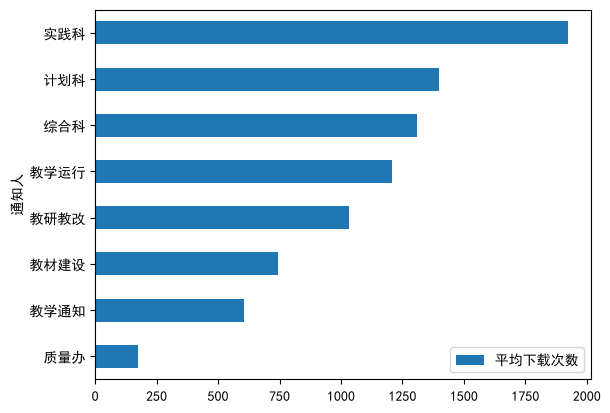

In [35]:
# 计算通知人的附件平均下载量
previous_informant = None
average_list = []
for idx, row in df_info_with_attachment.iterrows():

    if row["通知人"] != previous_informant:
        if previous_informant != None:
            info = {
                "通知人":previous_informant,
                "平均下载次数":quantity/num
            }
            average_list.append(info)
        num = row["附件数"]
        quantity = row["附件总下载次数"]
    
    else:
        num += row["附件数"]
        quantity += row["附件总下载次数"]
    previous_informant = row["通知人"]

info = {
    "通知人":previous_informant,
    "平均下载次数":quantity/num
}
if previous_informant != None:
    average_list.append(info)

# 排序并输出数据
average_list.sort(key=lambda x:x["平均下载次数"])

df_average_info = pd.DataFrame(average_list)

df_average_info.plot(kind='barh', x="通知人")
plt.show()

## 按日期分组并观察数量

df_data_group_1:          日期  消息数
0   2025-09    7
1   2025-10    5
2   2025-11   11
3   2025-12   14
4   2026-01   21
5   2026-02    7
6   2026-03   11
7   2026-04   17
8   2026-05   19
9   2026-06   18
10  2026-07    4
11  2026-08    5
12  2026-09   23


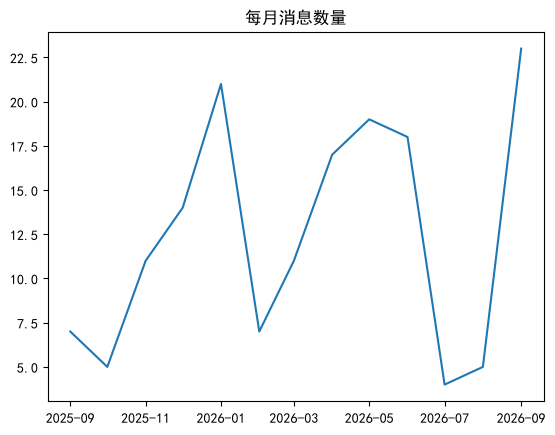

In [10]:
df_data_group = data.groupby(data["日期"].dt.to_period("M")).size().reset_index(name="消息数")
print("df_data_group_1:", df_data_group)
# 把Period转为datetime，方便matplotlib绘图
df_data_group["日期"] = df_data_group["日期"].dt.to_timestamp()

date_list = np.array(df_data_group["日期"].tolist())
num_list = np.array(df_data_group["消息数"].tolist())

plt.plot(date_list, num_list)

plt.title("每月消息数量")
plt.show()